In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# EDA

In [2]:
df = pd.read_csv('Training data/train.csv')
df_processed = pd.read_csv('df_processed.csv')
target = 'loan_paid_back'

<Axes: xlabel='loan_paid_back', ylabel='count'>

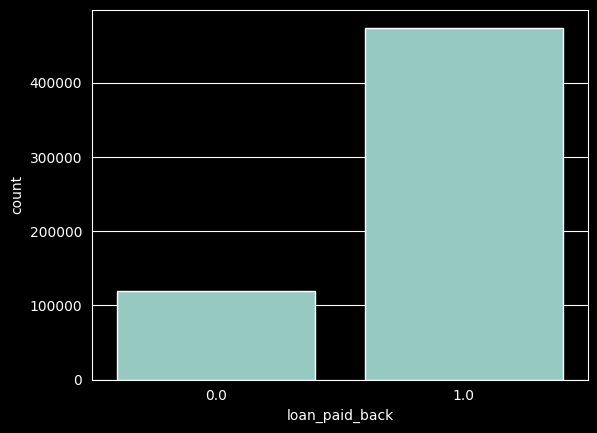

In [3]:
plt.figure(figsize=(10, 8))
sns.countplot(x = target, data = df)

The dataset exhibits a significant class imbalance, with the positive class ("1.0") accounting for approximately 80% of the observations. This distribution poses a challenge for traditional evaluation metrics; a "naive" model predicting only the majority class would achieve an 80% accuracy rate without capturing any underlying patterns. Consequently, this justifies the use of ROC AUC as our primary metric and the implementation of stratified cross-validation and class weighting (scale_pos_weight)  to ensure the model effectively learns the characteristics of the minority class

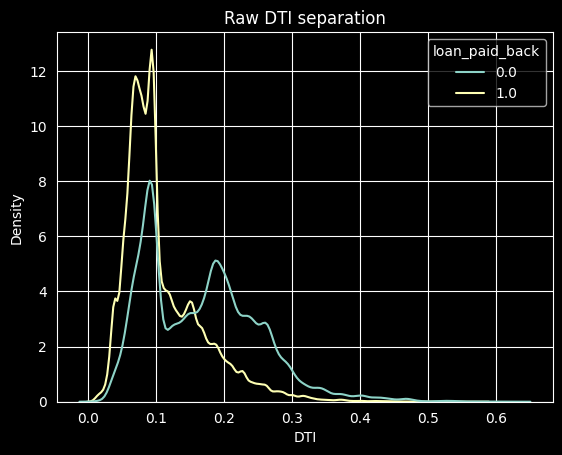

In [19]:
plt.figure(figsize=(10, 8))
sns.kdeplot( x= 'debt_to_income_ratio', hue = target, data=df, common_norm=False)
plt.title('Raw DTI separation')
plt.ylabel('Density')
plt.xlabel('DTI')
plt.show()

The raw Debt-to-Income (DTI) ratio shows a visible, yet insufficient, separation between classes.

- Defaulting class (0.0): Exhibits a slightly broader distribution with a more pronounced "hump" in the higher DTI range (around 0.2 – 0.3).

- Paying class (1.0): Shows a higher density at lower DTI levels (around 0.1), which is intuitively correct as lower debt usually implies lower risk.

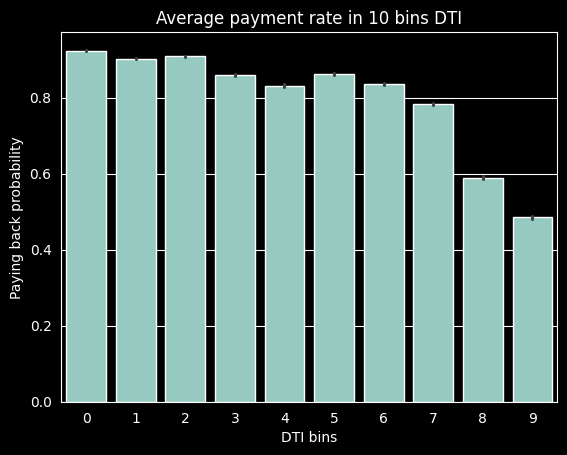

In [17]:
plt.figure(figsize=(10, 8))
sns.barplot(data = df_processed, x = 'debt_to_income_ratio_bin10', y = target)
plt.title('Average payment rate in 10 bins DTI')
plt.ylabel('Paying back probability')
plt.xlabel('DTI bins')
plt.show()

The impact of the Debt-to-Income ratio becomes significantly more apparent after discretization into 10 quantile-based bins (debt_to_income_ratio_bin10) . While the raw continuous variable suffered from noise and overlapping distributions, the binned version reveals a clear, monotonic downward trend in repayment probability.

/tmp/ipykernel_23456/261476463.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x=target, y='total_debt_income_ratio', palette='Set2')


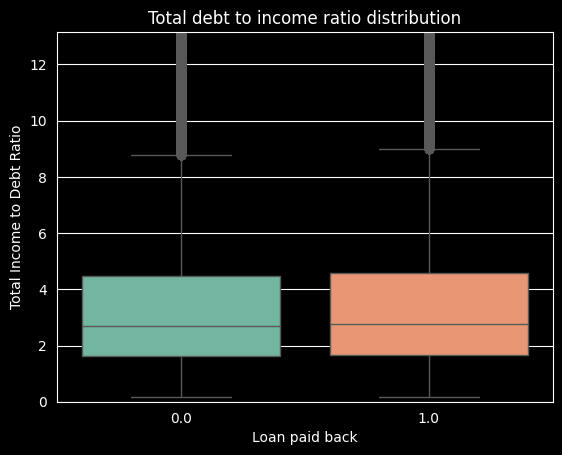

In [25]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_processed, x=target, y='total_debt_income_ratio', palette='Set2')
plt.title('Total income to debt ratio distribution')
plt.xlabel('Loan paid back')
plt.ylabel('Total Income to Debt Ratio')
upper_bound = df_processed['total_debt_income_ratio'].quantile(0.95)
plt.ylim(0, upper_bound)
plt.show()

After filtering out extreme outliers (the top 5% of the long tail) to visualize the core population, we can observe a subtle but consistent shift in the distribution. Both the median and the 75th percentile for the positive class (1.0 - Paid Back) are slightly elevated compared to the negative class (0.0 - Default).

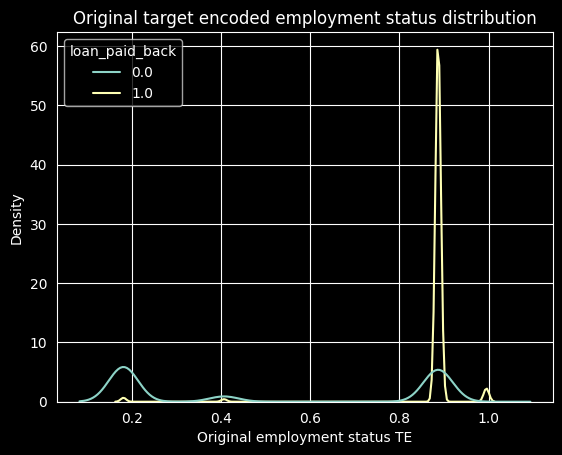

In [27]:
plt.figure(figsize=(10, 8))
sns.kdeplot( x= 'orig_employment_status_te', hue = target, data=df_processed, common_norm=False)
plt.title('Original target encoded employment status distribution')
plt.ylabel('Density')
plt.xlabel('Original employment status TE')
plt.show()

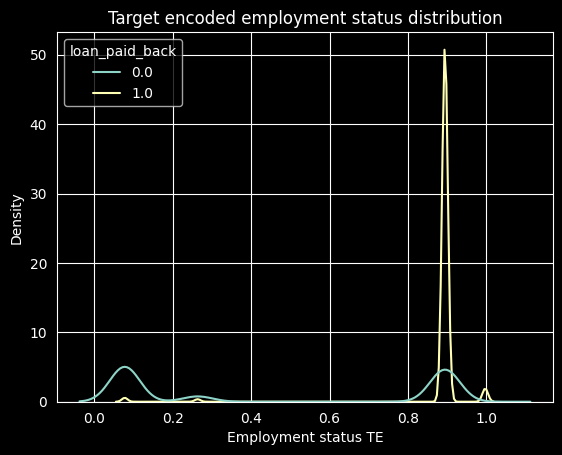

In [26]:
plt.figure(figsize=(10, 8))
sns.kdeplot( x= 'mean_employment_status', hue = target, data=df_processed, common_norm=False)
plt.title('Target encoded employment status distribution')
plt.ylabel('Density')
plt.xlabel('Employment status TE')
plt.show()

The plots visualize why Target Encoding (TE) of employment status consistently emerged as the most significant predictor across all model iterations.

- Original Dataset TE: Using the broader context from the original dataset provided a sharp, high-density peak for the positive class.

- OOF Training Set TE: The 7-fold Out-Of-Fold (OOF) implementation successfully replicated this signal within the training loop without introducing data leakage.

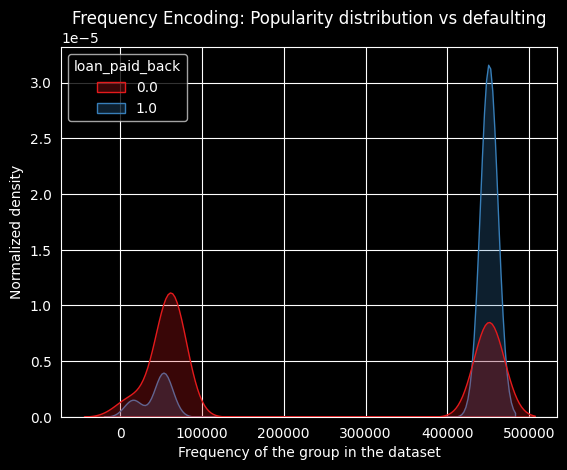

In [29]:
plt.figure(figsize=(10, 8))
sns.kdeplot(data=df_processed, x='employment_status_freq', hue=target, common_norm=False, fill=True, palette='Set1')
plt.title('Frequency Encoding: Popularity distribution vs defaulting')
plt.xlabel('Frequency of the group in the dataset')
plt.ylabel('Normalized density')
plt.show()

By transforming categorical identifiers into their frequency counts, we expose a distinct behavioral pattern. The normalized density plot reveals that the negative class exhibits noticeably distinct peaks in the lower-frequency regions compared to the positive class.

/tmp/ipykernel_23456/1008232908.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top,


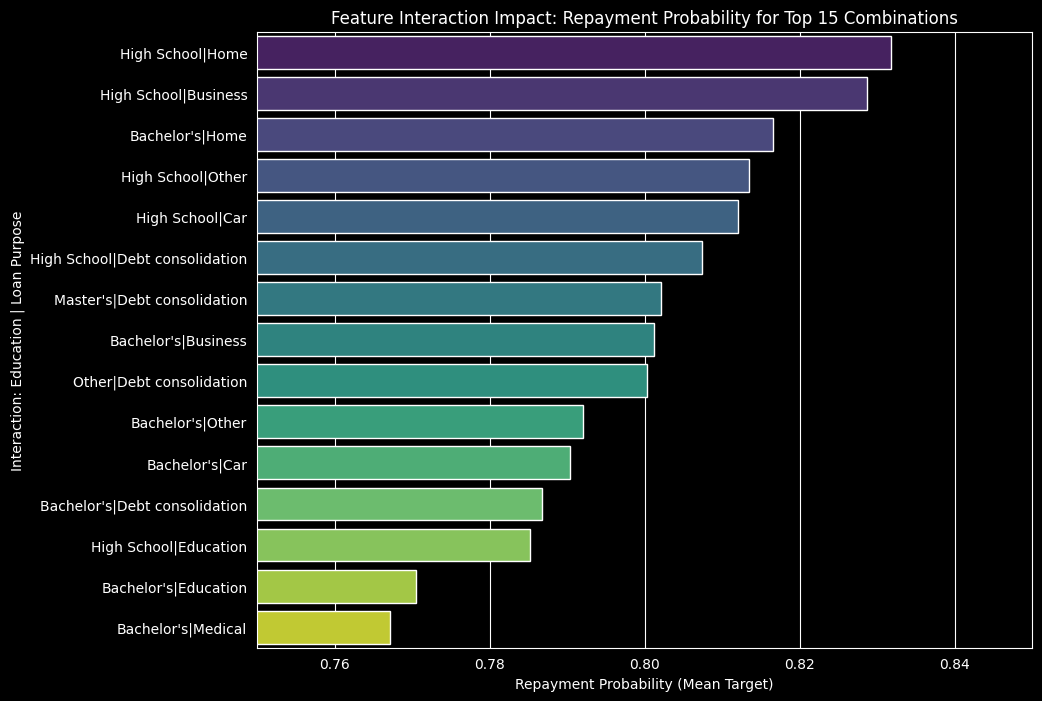

In [35]:
plt.figure(figsize=(10, 8))

top_categories = df_processed['education_level|loan_purpose'].value_counts().nlargest(15).index
df_top = df_processed[df_processed['education_level|loan_purpose'].isin(top_categories)]

order = df_top.groupby('education_level|loan_purpose')[target].mean().sort_values(ascending=False).index

sns.barplot(data=df_top,
            x=target,
            y='education_level|loan_purpose',
            order=order,
            palette='viridis',
            errorbar=None)

plt.xlim(0.75, 0.85)

plt.title('Feature Interaction Impact: Repayment Probability for Top 15 Combinations')
plt.xlabel('Repayment Probability (Mean Target)')
plt.ylabel('Interaction: Education | Loan Purpose')
plt.show()

By creating an explicit interaction between education_level and loan_purpose, we uncover localized risk profiles that individual features might obscure. The zoomed-in visualization reveals a variance in repayment probability across the top 15 combinations, ranging from ~77% to over 83%.

# Conclusion

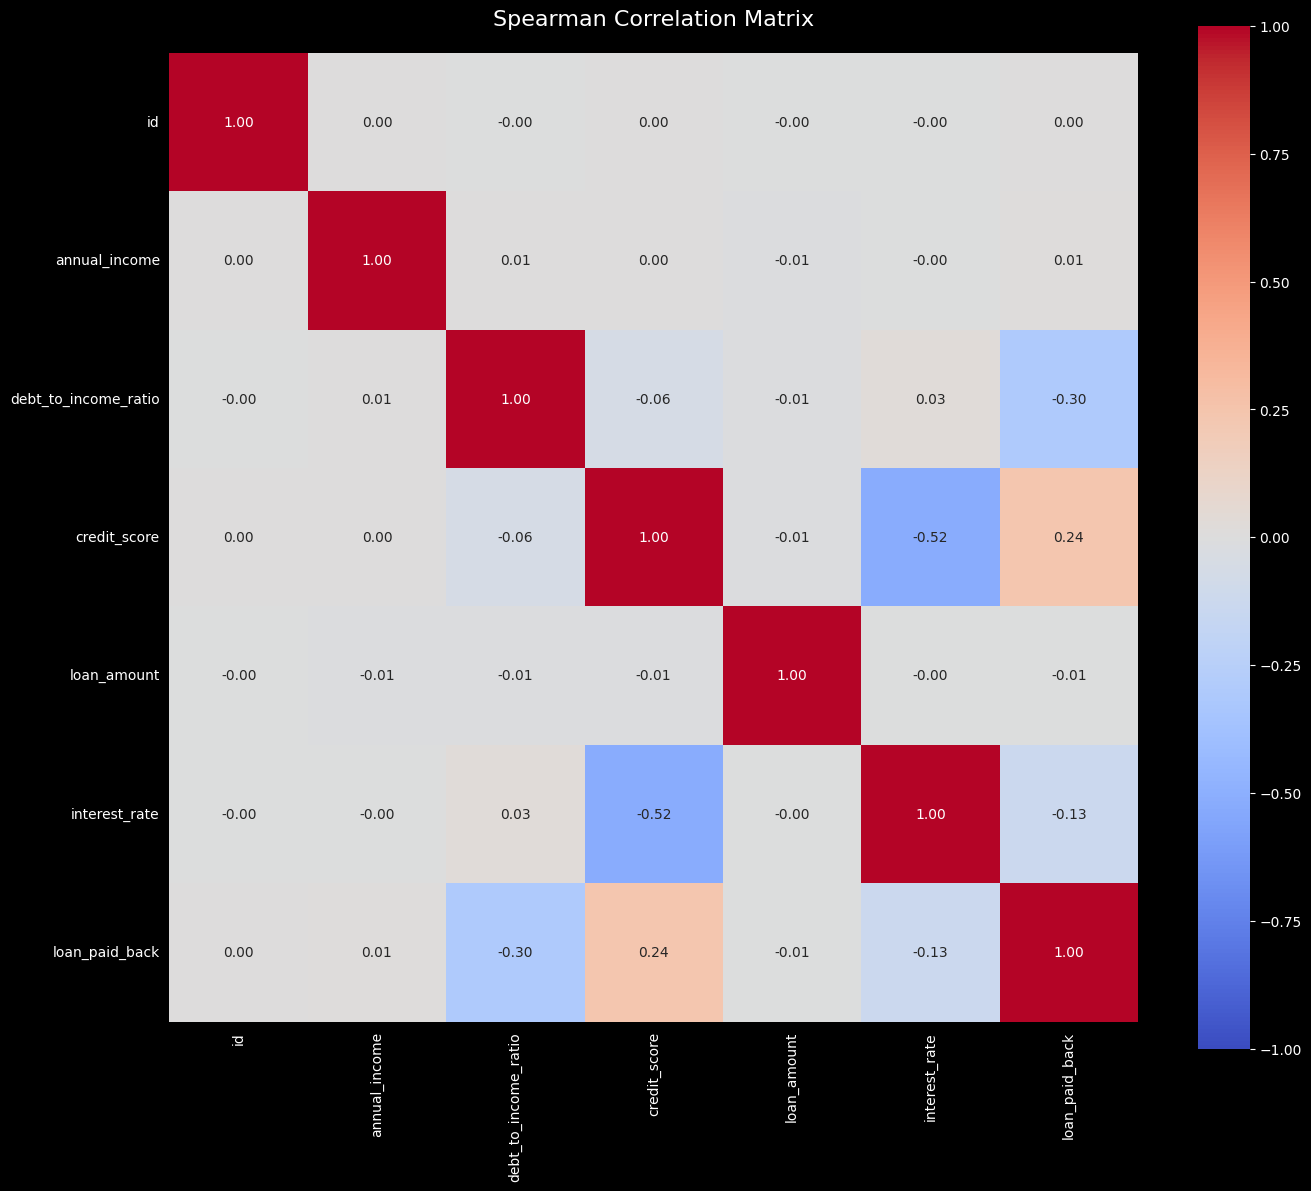

In [47]:
numeric_df = df.select_dtypes(include=[np.number])

corr_with_target = numeric_df.corr(method='spearman')[target].abs().sort_values(ascending=False)

top_corr_matrix = numeric_df.corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True,
            square=True,
            vmin=-1, vmax=1)

plt.title('Spearman Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

The initial correlation matrix for raw numerical features reveals a significant lack of linear or monotonic relationship with the target variable (loan_paid_back). Most features, such as annual_income or loan_amount, show near-zero correlation scores. The strongest signals come from debt_to_income_ratio (-0.30) and credit_score (0.24), but even these are relatively weak for high-precision modeling.

This "silent" correlation matrix serves as the primary justification for the advanced encoding techniques implemented in this project:

- Target & Frequency Encoding: These were essential to transform categorical and high-cardinality numerical data into probability-based signals that the model can actually interpret .
- Discretization (Binning): By grouping continuous variables, we exposed hidden non-linear trends that are invisible to standard correlation coefficients .
- Interaction Terms: Features like total_debt_income_ratio were created to synthesize multiple weak signals into a single, more robust predictor .

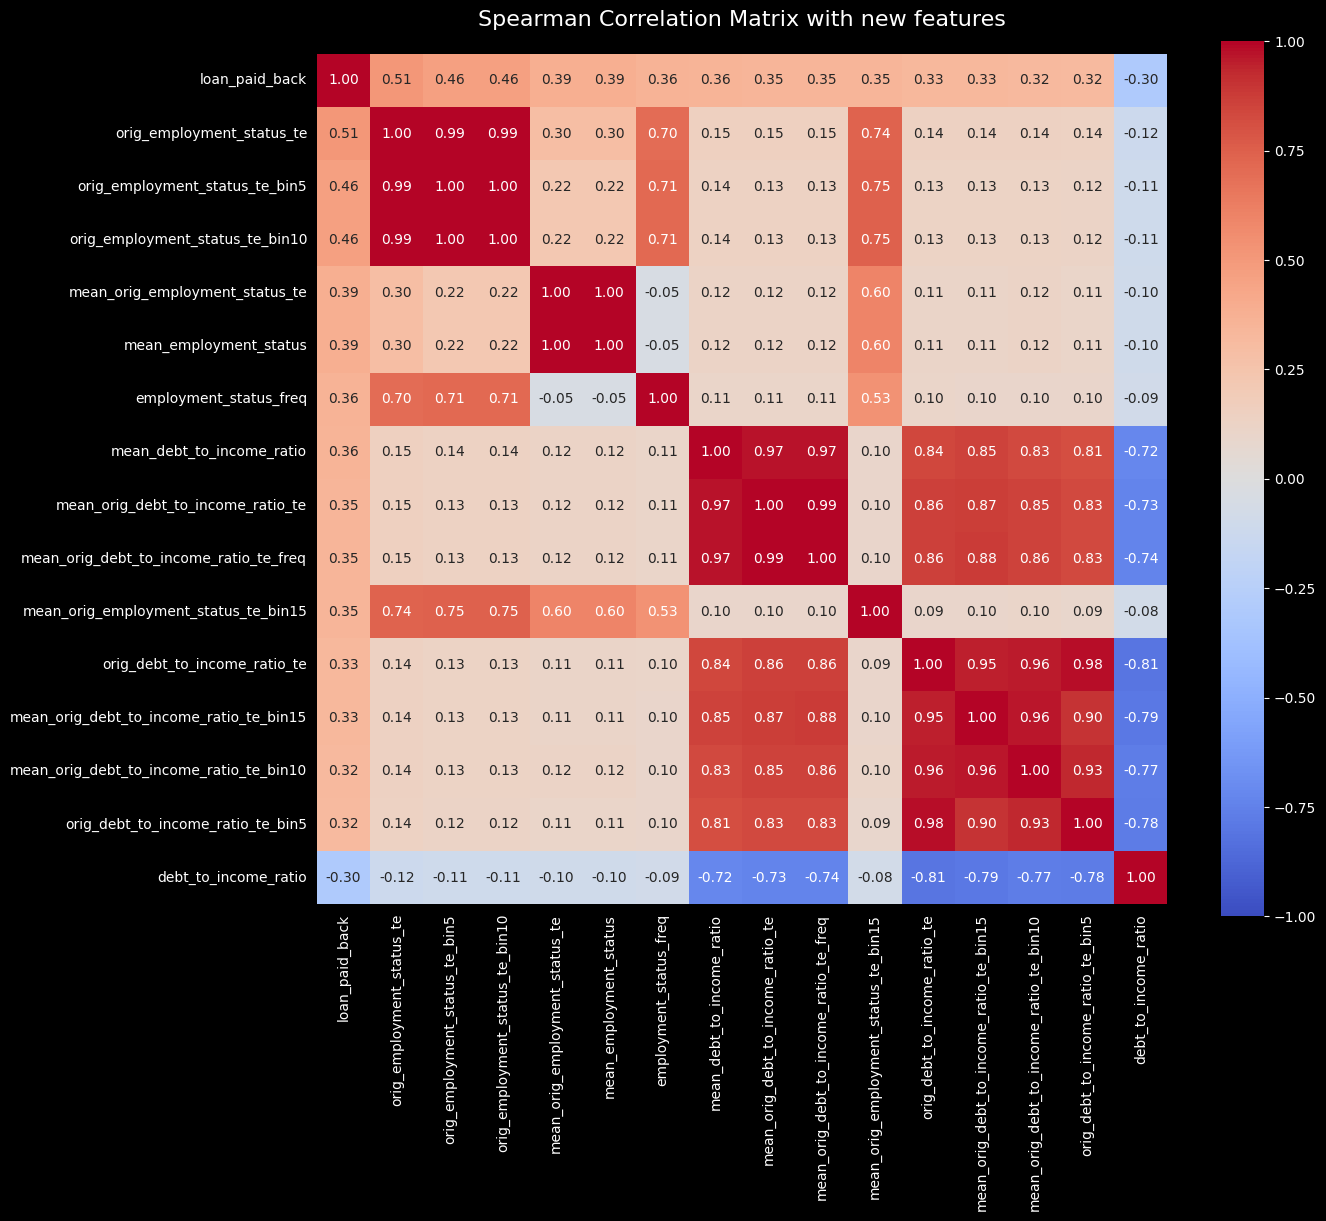

In [52]:
numeric_df_processed = df_processed.select_dtypes(include=[np.number])
corr_with_target = numeric_df_processed.corr(method='spearman')[target].abs().sort_values(ascending=False)

top_15_features = corr_with_target.head(16).index

top_corr_matrix_processed = numeric_df_processed[top_15_features].corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix_processed,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True,
            square=True,
            vmin=-1, vmax=1)

plt.title('Spearman Correlation Matrix with new features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

The introduction of engineered features has dramatically transformed the correlation landscape. While raw numerical columns showed negligible relationships with the target, our new predictors exhibit strong monotonic signals.

- Top Predictors: Features derived from employment_status and debt_to_income_ratio using Target Encoding (_te) and Out-Of-Fold (OOF) methods  show Spearman coefficients as high as 0.51 and 0.46 with loan_paid_back.

- Clustering: We can observe clear "clusters" of highly correlated features (e.g., the red blocks indicating correlations of 0.95-1.00) . This is expected, as many features are variations of the same underlying data (binning vs. encoding vs. frequency) .